In [43]:
#####let's see the output

In [1]:
from lics_unwrap import *
import re, os, glob
import xarray as xr
from scipy.constants import speed_of_light
import h5py
import numpy as np
import cmcrameri.cm as cmc
import lics_tstools as lts

setting pyproj data directory


In [10]:
frame = ['014A_05232_242525','021D_05266_252525', '116A_05207_252525']
workdir='/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/sbois_final/inter/inter2020/'
cumfile=os.path.join(workdir, f'{frame[1]}/TS_GEOCml10/cum.h5')
framefile=os.path.join(workdir,frame[1])
tide_vel_file = os.path.join(framefile, 'tide.vel')
iono_vel_file = os.path.join(framefile, 'iono.vel')
vel_file=os.path.join(framefile, frame[1]+'.vel_filt.mskd.eurasia.geo.tif')
# Load cumulative displacement dataset
cuma = xr.load_dataset(cumfile)

In [11]:
from lics_unwrap import *
import re, os, glob
import xarray as xr
from scipy.constants import speed_of_light
import h5py
import numpy as np
import cmcrameri.cm as cmc
import lics_tstools as lts
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import pygmt

def create_geogrid(data_array, corner_lon, corner_lat, post_lon, post_lat):
    """Create georeferenced xarray DataArray for PyGMT plotting."""
    ny, nx = data_array.shape
    lons = corner_lon + np.arange(nx) * post_lon
    lats = corner_lat + np.arange(ny) * post_lat
    if post_lat < 0:
        lats = lats[::-1]
        data_array = data_array[::-1, :]
    return xr.DataArray(data_array, coords={"lat": lats, "lon": lons}, dims=["lat", "lon"], name="z")

# Extract metadata
corner_lon, corner_lat = cuma.corner_lon.item(), cuma.corner_lat.item()
post_lon, post_lat = cuma.post_lon.item(), cuma.post_lat.item()

# Convert imdates to datetime
imdates = pd.to_datetime(cuma['imdates'].values.astype(str), format='%Y%m%d')

# Select indices for the first image in March, June, September, December 2018
target_months = [3, 6, 9, 12]
selected_indices = []
for month in target_months:
    matches = [i for i, d in enumerate(imdates) if d.year == 2018 and d.month == month]
    if matches:
        selected_indices.append(matches[0])

# Initialize dictionary to store all grids
grids = {}

# Create geogrids for each correction type and month
for dataset_name, dataset_key in zip(["tide", "iono"], ["tide", "iono"]):
    dataset = cuma[dataset_key]
    for i, idx in enumerate(selected_indices):
        label = f"{dataset_name}_{i+1}"  # e.g., gacos_1, tide_2, etc.
        array = dataset[idx].values
        grid = create_geogrid(array, corner_lon, corner_lat, post_lon, post_lat)
        grids[label] = grid


# Region

shape = cuma.vel.shape
region = [corner_lon, corner_lon + shape[1] * post_lon,
          corner_lat + shape[0] * post_lat, corner_lat]

#prepareing dem for figure
###demfile
dem_file='earth_relief_fullAHB_30s.nc'
# Upload data
batchdir = '/work/scratch-pw2/licsar/mnergiz/batchdir'
dem = os.path.join(batchdir, dem_file)
dem_resolution='30s'
merged_dir = '/home/users/mnergiz/1.gmt_workout/2.turkey_paper/merged_track_polys'
tr1_dir='/home/users/mnergiz/1.gmt_workout/1.turkey_paper'
fault_file=f'{tr1_dir}/data/GEM_NAEF.shp'
#####
# DEM downloading
if not os.path.exists(dem):
    print('DEM is downloading please wait! After downloading, the process will be faster!')
    try:
        # Download the earth relief data and save it to a file
        grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
        # Saving the grid to a NetCDF file
        grid.to_netcdf(dem)
        print(f"Data successfully downloaded and saved to {dem}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f'DEM already exists!')


fig = pygmt.Figure()
pygmt.config(
    MAP_FRAME_PEN='0.7p,black',
    FONT_LABEL='12p,Helvetica',
    FONT_ANNOT='10p,Helvetica',
    MAP_FRAME_TYPE="inside",
    FORMAT_GEO_MAP="DD"
)

# Custom ordering for row-wise layout
ordered_labels = [
    "tide_1",  "tide_2",  "tide_3",  "tide_4",
    "iono_1",  "iono_2",  "iono_3",  "iono_4"
]

# Step 1: Define groupings
groups = {
    "tide": ordered_labels[0:4],
    "iono": ordered_labels[4:8]
}

# Step 2: Compute vmin/vmax for each group
group_vlims = {}
for key, labels in groups.items():
    all_data = np.concatenate([grids[l].data.flatten() for l in labels])
    vmin, vmax = np.nanpercentile(all_data, [2, 98])
    lim = max(abs(vmin), abs(vmax))
    print(f"vmin/vmax for {key}: {vmin:.2f}/{vmax:.2f}")
    print(f"-lim/lim for {key}: {-lim:.2f}/{lim:.2f}")
    group_vlims[key] = (vmin, vmax)
    group_vlims[key] = (-lim, lim)  # symmetric color range

# Step 3: Plot loop
for i, label in enumerate(ordered_labels):
    row = i // 4
    col = i % 4
    group_key = label.split("_")[0]  # 'gacos', 'tide', or 'iono'

    # Shift panel origin
    if i > 0:
        if col == 0:
            fig.shift_origin(xshift="-12.3c", yshift="-6.3c")
        else:
            fig.shift_origin(xshift="4.1c")

    grid = grids[label]

    # Plot base map
    fig.basemap(projection="M4c", region=region, frame=True)

    # Background DEM
    pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
    fig.grdimage(grid=dem, cmap=True, region=region, shading=True, frame=False)

    # Shared CPT per group
    vmin, vmax = group_vlims[group_key]
    pygmt.makecpt(cmap='vik', series=[vmin, vmax])

    # Main overlay
    fig.grdimage(grid=grid, cmap=True, nan_transparent=True)
    fig.coast(shorelines="black", water="skyblue")

    # Step 4: Only plot colorbar for the last panel in each row (4th column)
    pygmt.config(MAP_FRAME_TYPE="plain")
    if col == 3:
        fig.colorbar(
            position="JMR+o0.5c/0c+e",  # Right of the panel
            frame=f'a{int(abs(vmax))}f{int(abs(vmax))/2}',
            cmap=True
        )
    pygmt.config(MAP_FRAME_TYPE="inside")
    fig.basemap(projection="M4c", region=region, frame=True)
    

# fig.show()
fig.savefig(f'Correction_LiCSAR_SBOI_{frame[1]}.png', dpi=500)


DEM already exists!
vmin/vmax for tide: -2.88/3.91
-lim/lim for tide: -3.91/3.91
vmin/vmax for iono: -9.21/10.53
-lim/lim for iono: -10.53/10.53


In [12]:
for month in target_months:
    matches = [i for i, d in enumerate(imdates) if d.year == 2018 and d.month == month]
    if matches:
        selected_indices.append(matches[0])

In [13]:
selected_indices

[100, 116, 129, 141, 100, 116, 129, 141]

In [15]:
print(imdates[0],imdates[100], imdates[116],imdates[129],imdates[141])

2016-01-30 00:00:00 2018-03-02 00:00:00 2018-06-06 00:00:00 2018-09-10 00:00:00 2018-12-03 00:00:00


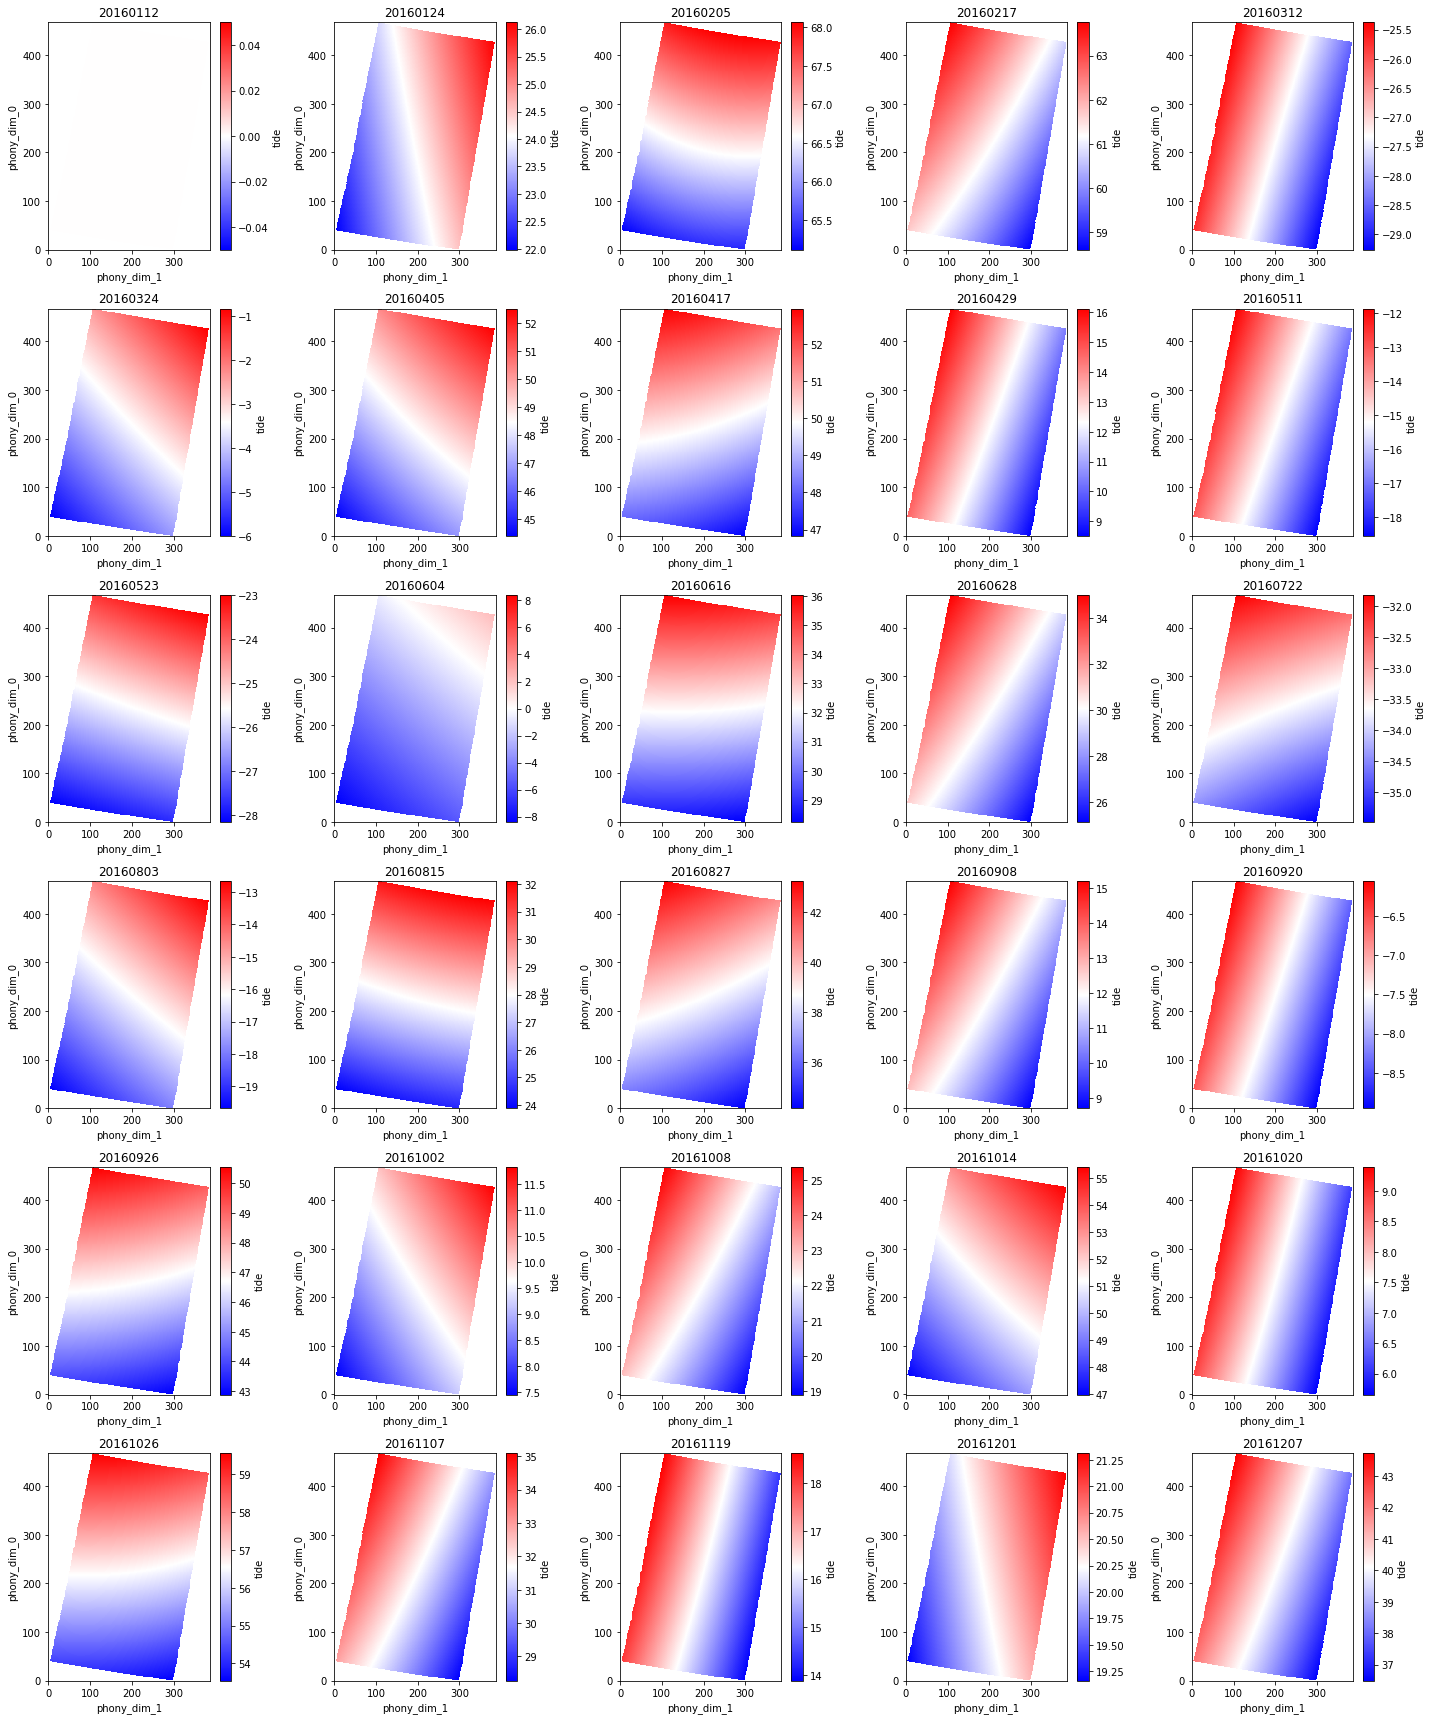

In [52]:
# Select the first 30 slices of cuma.tide
tide_data = cuma['tide']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


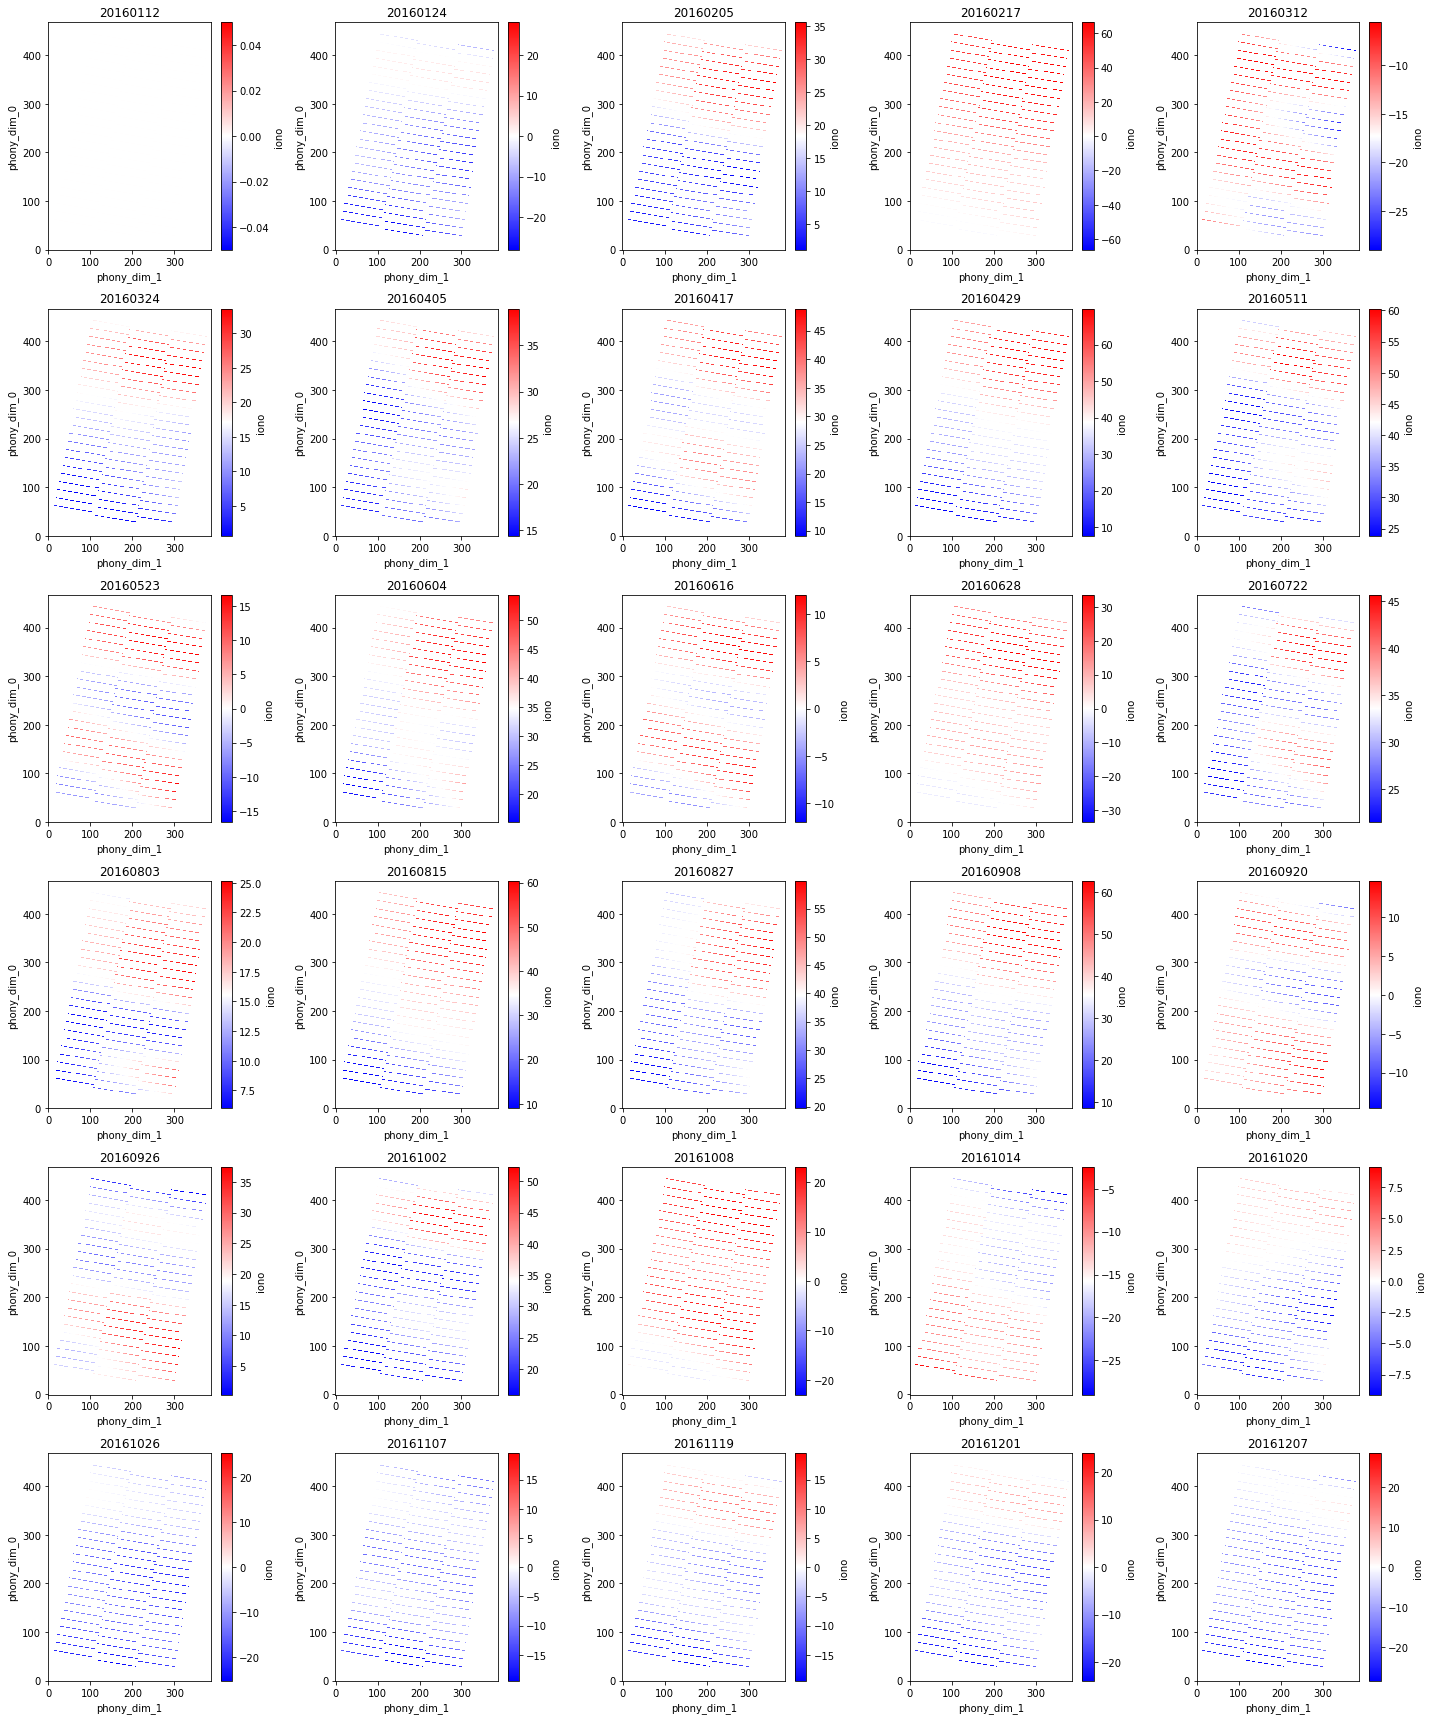

In [53]:
# Select the first 30 slices of cuma.tide
tide_data = cuma['iono']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


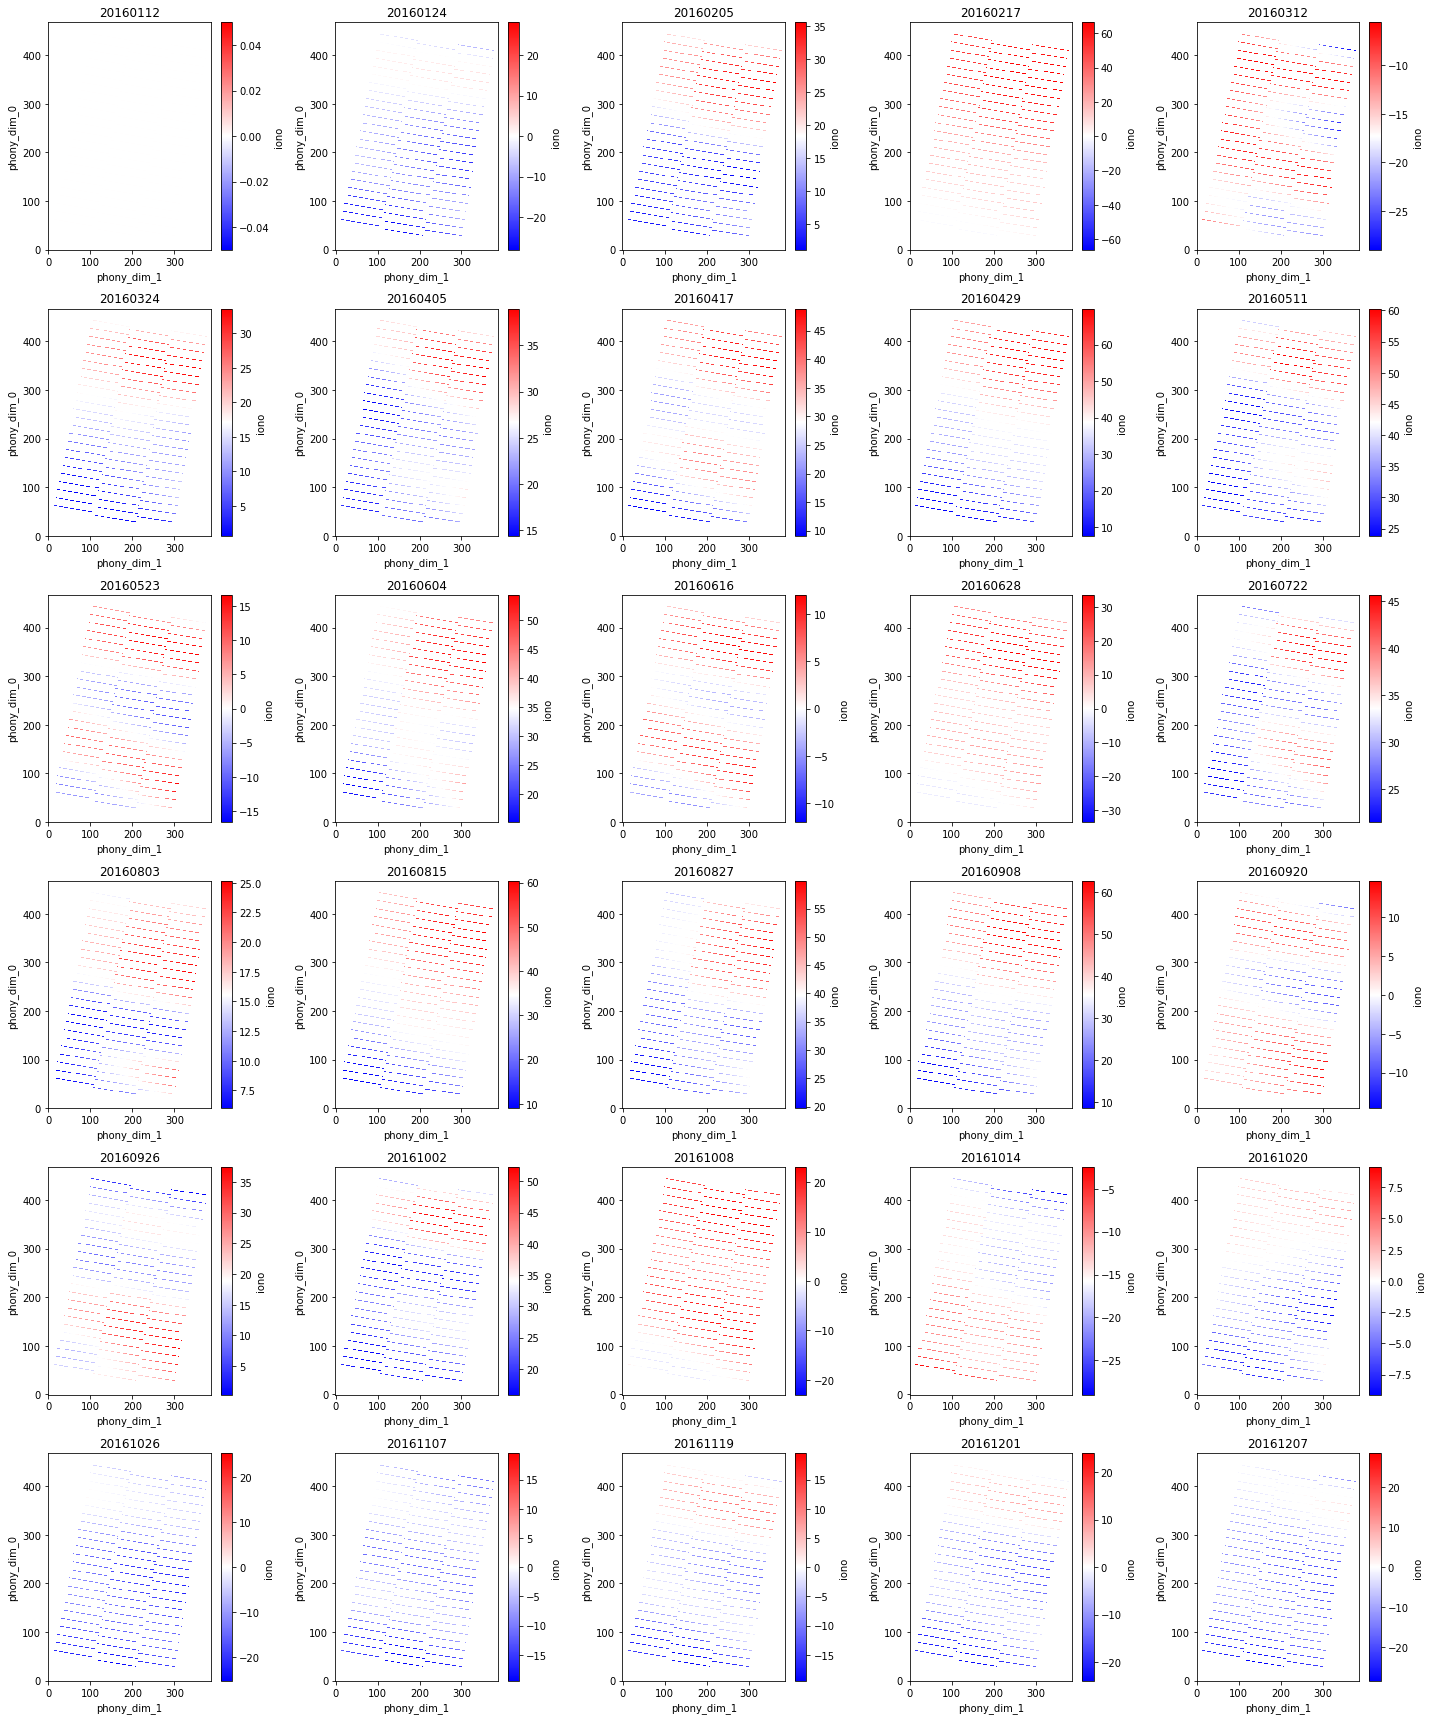

In [54]:
# Select the first 30 slices of cuma.tide
tide_data = cuma['iono']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


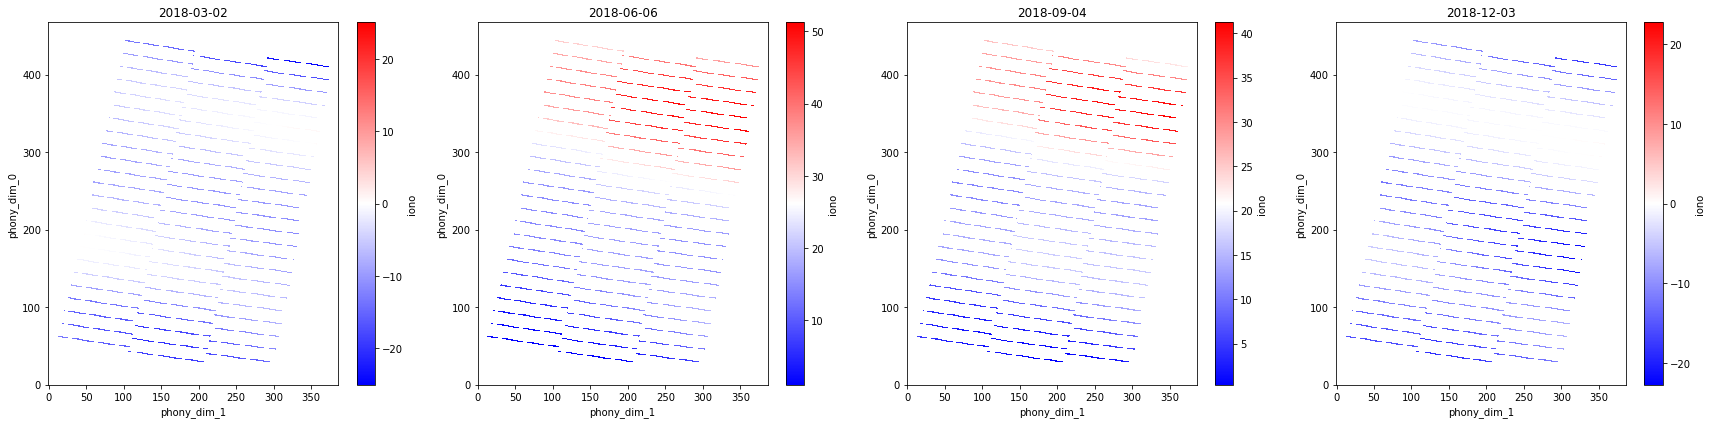

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert imdates to datetime
imdates = pd.to_datetime(cuma['imdates'].values.astype(str), format='%Y%m%d')
tide_data = cuma['iono']

# Select the first acquisition from each target month in 2018
target_months = [3, 6, 9, 12]
selected_indices = []

for month in target_months:
    # Filter imdates for 2018 and the current month
    matches = [i for i, d in enumerate(imdates) if d.year == 2018 and d.month == month]
    if matches:
        selected_indices.append(matches[0])  # Take the first date in that month

# Set up a 1x4 subplot
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, idx in zip(axes, selected_indices):
    tide_data[idx].plot(ax=ax, cmap='bwr')
    ax.set_title(imdates[idx].strftime('%Y-%m-%d'))

plt.tight_layout()
plt.show()


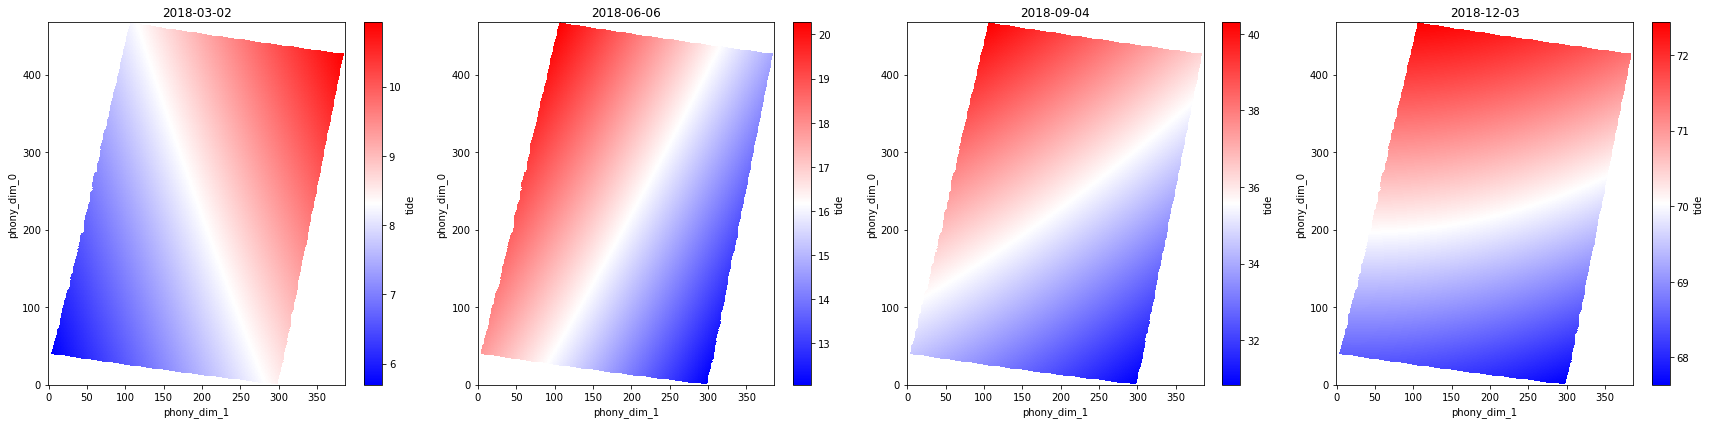

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert imdates to datetime
imdates = pd.to_datetime(cuma['imdates'].values.astype(str), format='%Y%m%d')
tide_data = cuma['tide']

# Select the first acquisition from each target month in 2018
target_months = [3, 6, 9, 12]
selected_indices = []

for month in target_months:
    # Filter imdates for 2018 and the current month
    matches = [i for i, d in enumerate(imdates) if d.year == 2018 and d.month == month]
    if matches:
        selected_indices.append(matches[0])  # Take the first date in that month

# Set up a 1x4 subplot
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, idx in zip(axes, selected_indices):
    tide_data[idx].plot(ax=ax, cmap='bwr')
    ax.set_title(imdates[idx].strftime('%Y-%m-%d'))

plt.tight_layout()
plt.show()
